In [22]:
from spin_lattices import SpinLattice, KagomeLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import FourierSeries, keep_largest_n
import numpy as np
from lattice_boolean_analysis import (
    LBFFromSpinSystem,
    LBFFromEigenstateSeries,
    SignalKind,
    SignSignalKind,
    ComposedSignalKind,
    KeepOnlyStatesSignalKind,
    AmplitudeMedianBinSignalKind,
    AmplitudeSignalKind,
    LogAmplitudeSignalKind,
    ProbabilityDistributionMedianBinSignalKind,
)
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import itertools
import numpy.typing as npt

In [2]:
lattice = KagomeLattice(2, 4)
system = HeisenbergJ1J2(lattice, 1, 1, use_symmetries=True, spin_inversion=None)
system.get_eigenstates(1)

2023-09-26 12:32:35.281 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:32:35.294 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:32:35.295 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis


2023-09-26 12:32:35.477 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 170028
2023-09-26 12:32:35.496 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-None-1.pickle
2023-09-26 12:32:35.553 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -42.8245991763


(array([-42.82459918]),
 array([[ 2.60810111e-07],
        [ 7.67101277e-08],
        [ 2.02298281e-18],
        ...,
        [-6.73840541e-03],
        [ 4.52846685e-03],
        [ 3.94649639e-03]]))

In [3]:
def make_training_set(system: SpinSystem, eps_train: float = 0.01):
    state_info_df = system.lattice.get_state_info_df(
        use_symmetries=True, hamming_weight=system.number_spins // 2, spin_inversion=1
    )
    representative_probs = (
        system.get_df_ground_state(add_amplitude=False)
        .assign(prob=lambda df: np.abs(df["eigenstate_coeff"]) ** 2)
        .join(state_info_df)
        .groupby("representative")["prob"]
        .sum()
    )
    representatives, _, _ = system.basis.state_info(system.canonical_basis.states)
    sample_size = int(system.basis.states.shape[0] * eps_train)
    print(f"{sample_size=}")
    train_sample_reprs = np.random.choice(
        representative_probs.index, p=representative_probs.to_numpy(), size=sample_size, replace=False
    )
    selected_states = system.canonical_basis.states[np.in1d(representatives, train_sample_reprs)]
    return selected_states

In [10]:
lattice = KagomeLattice(2, 4)
test_size = 10000
results = []
target_signal_kind = ProbabilityDistributionMedianBinSignalKind()
scorer = 'sign_overlap'

for J2, eps_train, keep_largest in itertools.product(
    [0.0, 0.2,  0.4,  0.6,  0.8,  1], [0.001],
    [100, 1000, 10000]
):
    system = HeisenbergJ1J2(lattice=lattice, J1=1, J2=J2, use_symmetries=True, spin_inversion=1)
    system.get_eigenstates(1)

    train_states = make_training_set(system, eps_train=eps_train)
    train_signal_kind = ComposedSignalKind(
        [
            KeepOnlyStatesSignalKind(train_states),
            target_signal_kind,
        ]
    )
    signal_train = LBFFromSpinSystem(system, kind=train_signal_kind)
    series = FourierSeries.from_signal(signal_train)

    test_set = np.random.choice(
        np.setdiff1d(system.canonical_basis.states, train_states), size=test_size
    )
    signal_test = LBFFromSpinSystem(system, kind=target_signal_kind)
    series_test = FourierSeries(signal_test, series.coeffs)
    score, _ = series_test.truncate(strategy=keep_largest_n(keep_largest)).prediction_score(
        scorer, test_set
    )
    results.append(
        {
            "J2": J2,
            "eps_train": eps_train,
            "score": score,
            "signal_kind": target_signal_kind.name,
            "scorer": scorer,
            "keep_largest": keep_largest,
        }
    )

2023-09-26 12:37:05.693 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:37:05.707 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:37:05.709 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-26 12:37:05.844 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 85662
2023-09-26 12:37:05.864 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-09-26 12:37:05.868 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:117 - Ground state energy is -46.1341392314
2023-09-26 12:37:07.041 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:234 - Finding basis_state_info
2023-09-26 12:37:07.968 | DEBUG    | heisenberg_hamiltonians:get_ground_state_in_canonical_basis:237 - Finding corresp_repr_indic

sample_size=85


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = self.get_ground_state_in_canonical_basis()
2023-09-26 12:37:12.828 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:37:17.567 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:37:17.583 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:37:17.585 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-26 12:37:17.587 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 85662
2023-09-26 12:37:17.605 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-09-26 12:37:17.608 | DEBUG    | heisenberg_hamiltonians:get

sample_size=85


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = self.get_ground_state_in_canonical_basis()
2023-09-26 12:37:22.836 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:37:27.459 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:37:27.473 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:37:27.475 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-26 12:37:27.476 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 85662
2023-09-26 12:37:27.494 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-0.0-True-1-1.pickle
2023-09-26 12:37:27.497 | DEBUG    | heisenberg_hamiltonians:get

...

/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = self.get_ground_state_in_canonical_basis()
2023-09-26 12:39:37.661 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:39:42.419 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:39:42.431 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:39:42.433 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-26 12:39:42.434 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 85662
2023-09-26 12:39:42.452 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
2023-09-26 12:39:42.455 | DEBUG    | heisenberg_hamiltonians:get

sample_size=85


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = self.get_ground_state_in_canonical_basis()
2023-09-26 12:39:47.558 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:39:52.204 | DEBUG    | heisenberg_hamiltonians:__init__:472 - number_spins=24
2023-09-26 12:39:52.213 | DEBUG    | heisenberg_hamiltonians:__init__:482 - Symmetry group contains 16 elements
2023-09-26 12:39:52.214 | DEBUG    | heisenberg_hamiltonians:__init__:483 - Constructing basis
2023-09-26 12:39:52.216 | DEBUG    | heisenberg_hamiltonians:__init__:491 - Hilbert space dimension is 85662
2023-09-26 12:39:52.233 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:69 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-1.0-1.0-True-1-1.pickle
2023-09-26 12:39:52.236 | DEBUG    | heisenberg_hamiltonians:get

sample_size=85


/vol/tcm10/ischurov/frustrations-eda/heisenberg_hamiltonians.py:205: ComplexWarning: Casting complex values to real discards the imaginary part
  coeffs[self.canonical_basis.states] = self.get_ground_state_in_canonical_basis()
2023-09-26 12:39:57.300 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 


/tmp/nix-shell.i1wLC2/ipykernel_371319/2171790112.py:3: UserWarning: 
The markers list has fewer values (1) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.relplot(
/nix/store/525hx0cz3k0s2nya7r7rai9s4rr5q4kd-python3-3.10.12-env/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


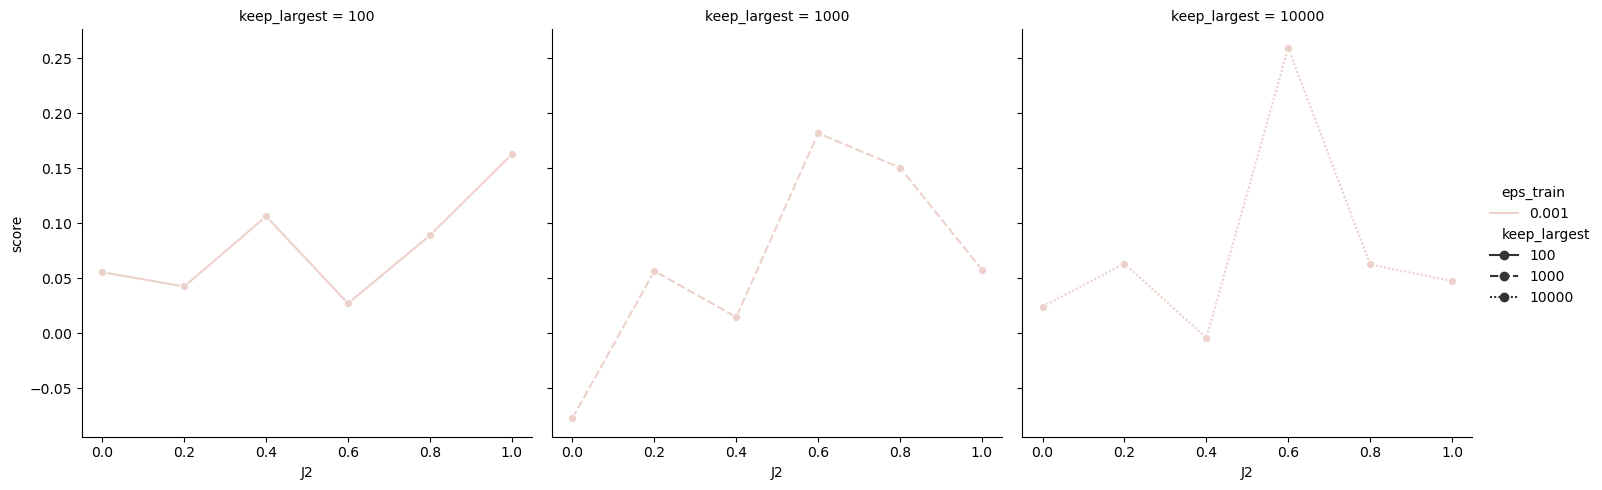

In [11]:
df = pd.DataFrame(results)
# df['score'] = df['score'].apply(lambda x: x[0])
sns.relplot(
    data=df,
    x="J2",
    y="score",
    hue="eps_train",
    kind="line",
    markers=["o"],
    style="keep_largest",
    col="keep_largest",
    col_wrap=3,
)

In [34]:
FourierSeries.from_signal(
    LBFFromSpinSystem(system, kind=ProbabilityDistributionMedianBinSignalKind())
).how_many_terms_to_achieve_score(0.95, "sign_overlap")

2023-09-26 13:02:36.078 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal
2023-09-26 13:02:38.985 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 13:02:47.347 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=16777216
2023-09-26 13:02:51.739 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=8388608, score=1.0
2023-09-26 13:02:51.745 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-26 13:02:51.747 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=8388608
2023-09-26 13:02:56.207 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=4194304, score=0.9998851124771904
2023-09-26 13:02:56.210 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-

(True,
 847502,
 array([-1.01312709, -1.01012826, -0.99542761, ..., -0.99542761,
        -1.01012826, -1.01312709]))

In [14]:
FourierSeries.from_signal(
    LBFFromSpinSystem(system, kind=SignSignalKind())
).how_many_terms_to_achieve_score(0.95, "sign_overlap")

2023-09-26 12:45:28.682 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal
2023-09-26 12:45:28.955 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:45:32.366 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=16777216
2023-09-26 12:45:34.545 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=8388608, score=1.0
2023-09-26 12:45:34.547 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-26 12:45:34.550 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=8388608
2023-09-26 12:45:36.927 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=4194304, score=1.0
2023-09-26 12:45:36.930 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-26 12:45:36.932

(True,
 4962,
 array([0.15317678, 0.01964808, 0.06798553, ..., 0.06798553, 0.01964808,
        0.15317678]))

In [16]:
FourierSeries.from_signal(
    LBFFromSpinSystem(system, kind=AmplitudeMedianBinSignalKind())
).how_many_terms_to_achieve_score(0.9, "overlap")

2023-09-26 12:49:13.045 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal


2023-09-26 12:49:13.974 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 12:49:18.535 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:158 - At min_terms=1, score=1.0 >= target_score=0.9, so we can achieve the target score with 1 terms


(True,
 1,
 array([0.16118026, 0.16118026, 0.16118026, ..., 0.16118026, 0.16118026,
        0.16118026]))

In [17]:
FourierSeries.from_signal(
    LBFFromSpinSystem(system, kind=AmplitudeMedianBinSignalKind())
).truncate(keep_largest_n(1)).prediction_score('accuracy')

2023-09-26 12:50:10.569 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal
2023-09-26 12:50:11.594 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 


(1.0,
 array([0.16118026, 0.16118026, 0.16118026, ..., 0.16118026, 0.16118026,
        0.16118026]))

In [26]:
class AmplitudeMedianBinSignalKind(SignalKind):
    def transform_data(self, eigenstate_coeff: npt.NDArray[np.float64]) -> npt.NDArray[np.float64]:
        mask = eigenstate_coeff != 0
        abs_ = np.abs(eigenstate_coeff)
        return np.sign(abs_ - np.median(abs_[mask]))


In [33]:
FourierSeries.from_signal(
    LBFFromSpinSystem(system, kind=AmplitudeMedianBinSignalKind())
).how_many_terms_to_achieve_score(0.95, "sign_overlap")

2023-09-26 13:01:26.938 | DEBUG    | fast_boolean_analysis:fourier_expand:296 - Finding signal
2023-09-26 13:01:27.599 | DEBUG    | fast_boolean_analysis:fourier_expand:298 - Doing 
2023-09-26 13:01:31.423 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=16777216
2023-09-26 13:01:33.551 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=8388608, score=1.0
2023-09-26 13:01:33.554 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-26 13:01:33.555 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:164 - min_terms=1, max_terms=8388608
2023-09-26 13:01:35.788 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:167 - mid=4194304, score=1.0
2023-09-26 13:01:35.790 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:170 - score >= target_score, so we can decrease max_terms
2023-09-26 13:01:35.793

(True,
 10099,
 array([-1.20262384, -1.22594786, -1.10623217, ..., -1.10623217,
        -1.22594786, -1.20262384]))